<a href="https://colab.research.google.com/github/dineshsnkumar/pytorch-for-deep-learning/blob/main/pytorch-fundamentals/image_classifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch torchvision numpy matplotlib

### Data preperation

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda")

In [4]:
data_path = "./data"

#### Tranformation of data using Compose

In [5]:
mnist_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

In [6]:
train_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=True,
    download=True,
    transform=mnist_transform
)

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.40MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.0MB/s]


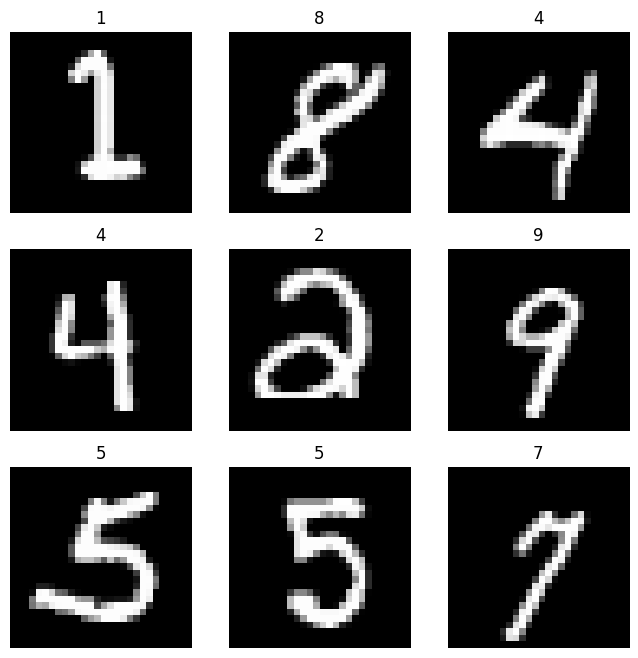

In [7]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3

for i in range(1, cols*rows + 1):
  sample_index = torch.randint(len(train_dataset), size=(1,)).item()
  img, label = train_dataset[sample_index]
  figure.add_subplot(rows, cols, i)
  plt.title(label)
  plt.axis("off")
  plt.imshow(img.squeeze(), cmap="gray")

plt.show()

In [8]:
test_dataset = torchvision.datasets.MNIST(
    root=data_path,
    train=False,
    download=True,
    transform=mnist_transform
)

In [9]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### Building the Model

In [10]:
class SimpleMNISTNN(nn.Module):
  def __init__(self):
    super(SimpleMNISTNN, self).__init__()
    self.flatten = nn.Flatten()
    self.layers = nn.Sequential(
        nn.Linear(784, 128),
        nn.ReLU(),
        nn.Linear(128, 10)
    )

  def forward(self, x):
    x = self.flatten(x)
    x = self.layers(x)
    return x

In [11]:
model = SimpleMNISTNN()
loss_function = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

### Training model

In [18]:
def train_model(model, loss_function, optimizer, train_loader, device):
  model = model.to(device)
  model.train()

  for batch_idx, (inputs, targets) in enumerate(train_loader):
    inputs, targets = inputs.to(device), targets.to(device)

    optimizer.zero_grad()
    outputs = model(inputs)
    loss = loss_function(outputs, targets)
    loss.backward()
    optimizer.step()

    if batch_idx % 100 == 0:
            loss = loss.item()
            print(f"loss: {loss:>7f}")



In [20]:
def evaluate(model, loss_function, test_loader, device):
  model.eval()
  size = len(test_loader.dataset)
  num_batches = len(test_loader)
  test_loss, correct = 0, 0

  with torch.no_grad():
    for inputs, targets in test_loader:
      inputs, targets = inputs.to(device), targets.to(device)
      outputs = model(inputs)

      test_loss += loss_function(outputs, targets).item()
      correct += (outputs.argmax(1) == targets).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")


In [21]:
epochs = 10

for epoch in range(epochs):
  print(f"Epoch {epoch+1}")
  train_model(model=model, loss_function=loss_function, train_loader=train_loader, device=device, optimizer=optimizer)
  evaluate(model, loss_function, test_loader, device)

Epoch 1
loss: 0.062228
loss: 0.419412
loss: 0.229593
loss: 0.330969
loss: 0.290699
loss: 0.374757
loss: 0.324498
loss: 0.109198
loss: 0.416563
loss: 0.279675
Test Error: 
 Accuracy: 94.9%, Avg loss: 0.207618 

Epoch 2
loss: 0.043715
loss: 0.132772
loss: 0.119582
loss: 0.149484
loss: 0.150588
loss: 0.258140
loss: 0.110357
loss: 0.203625
loss: 0.307660
loss: 0.452023
Test Error: 
 Accuracy: 94.5%, Avg loss: 0.225354 

Epoch 3
loss: 0.201315
loss: 0.162862
loss: 0.204306
loss: 0.042175
loss: 0.199628
loss: 0.355892
loss: 0.154714
loss: 0.093643
loss: 0.056672
loss: 0.271610
Test Error: 
 Accuracy: 94.6%, Avg loss: 0.221663 

Epoch 4
loss: 0.122228
loss: 0.062191
loss: 0.151159
loss: 0.209020
loss: 0.073226
loss: 0.625945
loss: 0.011955
loss: 0.049997
loss: 0.325600
loss: 0.245681
Test Error: 
 Accuracy: 95.2%, Avg loss: 0.216497 

Epoch 5
loss: 0.040429
loss: 0.043605
loss: 0.074946
loss: 0.058906
loss: 0.110636
loss: 0.127275
loss: 0.054213
loss: 0.143785
loss: 0.140353
loss: 0.139036
Te